In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import nifty8 as ift
import numpy as np
import resolve as rve

from jax.lax import slice as jax_slice
from copy import deepcopy
from scipy.ndimage import convolve1d

from aim_resolve import Observation, SignalSpace, plot_arrays, check_type

jax.config.update("jax_enable_x64", True)

Could not import MPI
/Users/rf/miniforge3/envs/aim/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [49]:
def build_exact_responses(obs, space):
    check_type(space, SignalSpace)
    sdom = ift.RGSpace(space.shape, distances=space.distances)
    sky_dom = rve.default_sky_domain(sdom=sdom)
    R = rve.InterferometryResponse(obs, sky_dom, True, 1e-9, verbosity=0, nthreads=8)

    space_l = space.multiply_fov(2)
    sdom_l = ift.RGSpace(space_l.shape, distances=space_l.distances)
    sky_dom_l = rve.default_sky_domain(sdom=sdom_l)
    R_l = rve.InterferometryResponse(obs, sky_dom_l, True, 1e-9, verbosity=0, nthreads=8)

    dch_l = ift.DomainChangerAndReshaper(R_l.domain[3], R_l.domain)
    R_l = R_l @ dch_l
    dch = ift.DomainChangerAndReshaper(R.domain[3], R.domain)
    R = R @ dch

    N_inv = ift.DiagonalOperator(obs.weight)
    RNR = R.adjoint @ N_inv @ R
    RNR_l = R_l.adjoint @ N_inv @ R_l

    return R, R_l, RNR, RNR_l


def compute_psf_kernel(RNR_l):
    dom_l = RNR_l.domain
    shp_l = dom_l.shape

    delta = np.zeros(shp_l)
    delta[shp_l[0]//2, shp_l[1]//2] = 1 / dom_l.scalar_weight()
    delta = ift.makeField(dom_l, delta)
    kernel = RNR_l(delta)

    return kernel.val


def compute_noise_kernel(RNR, relativ_min_val=0.):
    '''Build the inverse noise kernel for the given RNR operator.'''
    dom = RNR.domain
    shp = dom.shape
    FFT = ift.FFTOperator(RNR.domain)

    delta = np.zeros(shp)
    delta[shp[0]//2, shp[1]//2] = 1 / dom.scalar_weight()
    delta = ift.makeField(dom, delta)
    kernel = RNR(delta).val
    kernel = np.roll(kernel, -shp[0]//2, axis=0)
    kernel = np.roll(kernel, -shp[1]//2, axis=1)
    kernel = ift.makeField(RNR.target, kernel)
    FFT = ift.FFTOperator(RNR.domain)
    max_val = np.max(FFT(kernel).abs().val)
    min_val = relativ_min_val * max_val
    min_val = ift.full(FFT.target, min_val)
    min_val_adder = ift.Adder(min_val)

    pos_eig_val = ift.Operator.identity_operator(FFT.target).exp()
    pos_eig_val = min_val_adder @ pos_eig_val
    rls1 = ift.Realizer(pos_eig_val.target)
    rls2 = ift.Realizer(FFT.domain)

    kernel_pos = rls2 @ FFT.inverse @ rls1.adjoint @ pos_eig_val

    cov = ift.ScalingOperator(kernel_pos.target, 1e-2*max_val)
    lh = ift.GaussianEnergy(data=kernel, inverse_covariance=cov.inverse) @ kernel_pos
    init_pos = (FFT(kernel) - min_val).abs().log()
    energy = ift.EnergyAdapter(position=init_pos, op=lh, want_metric=True)

    ic_newton = ift.DeltaEnergyController(name='Newton', iteration_limit=80, tol_rel_deltaE=0)
    minimizer = ift.NewtonCG(ic_newton)
    res = minimizer(energy)[0].position

    return pos_eig_val(res).val


def fft_fun(space):
    check_type(space, SignalSpace)
    dvol = space.dis[0]
    return lambda x: dvol * jnp.fft.fftn(x)


def ifft_fun(space):
    check_type(space, SignalSpace)
    dvol = 1. / (space.shp[0] * space.dis[0])
    npix = space.shape[0]
    return lambda x: dvol * npix * jnp.fft.ifftn(x)


def shift_kernel(kernel):
    shifted_kernel = np.roll(kernel, -kernel.shape[0]//2, axis=0)
    shifted_kernel = np.roll(shifted_kernel, -kernel.shape[1]//2, axis=1)
    return shifted_kernel


def fft_convolve_1d(array, kernel, space, factor=1):
    fft_kernel = transform_psf_kernel(kernel, space, factor)
    res = apply_psf_kernel(fft_kernel, space*(1/factor))(array)
    return res


def crop_array(array, factor):
    target = array.size // factor
    cut = (array.size - target) // 2
    return array[cut:cut + target]


def transform_psf_kernel(kernel, space, factor=1):
    check_type(space, SignalSpace)
    space_l = space.multiply_fov(2)
    shift_kernel = jnp.roll(kernel, -kernel.shape[0]//2)
    fourier_kernel = fft_fun(space_l)(shift_kernel)

    if factor != 1:
        fourier_kernel = np.roll(fourier_kernel, -fourier_kernel.shape[0]//2)
        fourier_kernel = crop_array(fourier_kernel, factor)
        fourier_kernel = np.roll(fourier_kernel, fourier_kernel.shape[0]//2)

    return fourier_kernel


def apply_psf_kernel(kernel, space):
    space_l = space.multiply_fov(2)
    ft_kernel = jnp.array(kernel)

    fft_l = fft_fun(space_l)
    ifft_l = ifft_fun(space_l)
    shape = int(space.shp[0])
    padding = shape // 2

    def apply_psf(x):
        res = jnp.pad(x, 2 * (padding,))
        res = ifft_l(ft_kernel * fft_l(res)).real
        res = jax_slice(res, (padding,), (padding + shape,))
        return np.array(res)
    
    return apply_psf


def downsample(array, factor):
    if factor == 1:
        return array
    if factor in (2,4,8):
        return array.reshape(-1, factor).mean(axis=1)
    else:
        raise ValueError(f'Invalid zoom factor: {factor}')
    
def upsample(array, factor):
    if factor == 1:
        return array
    elif factor in (2, 4, 8):
        return array.repeat(factor)
    else:
        raise ValueError(f'Invalid zoom factor: {factor}')


def plot_1d(*arrays, figsize=(5,2), norm='linear', title='',
            offset=1, vmin=None, vmax=None, cmap='Paired'):
    plt.figure(figsize=figsize)
    colors = plt.colormaps.get_cmap(cmap)

    if norm == 'log':
        min_a = min([a[a > 0].min() for a in arrays if np.any(a > 0)])
    for i, a in enumerate(arrays):
        if a.size != arrays[0].size:
            raise ValueError("All arrays must have the same size")
        a = np.array(a)
        if norm == 'log':
            a[a <= 0] = min_a
        if offset:
            a = a[offset:-offset]
        plt.plot(np.arange(a.size), a, color=colors(i))

    plt.yscale(norm)
    if vmin is not None or vmax is not None:
        plt.ylim(vmin, vmax)
    plt.title(title)
    plt.show()

In [7]:
obs = Observation.load('/Users/rf/Development/data/eso_986-1137mhz.npz')
obs = obs.to_double_precision()
obs = obs.to_resolve_obs()
print(obs)

Observation:
  Source name:		None
  Visibilities shape:	(1, 3668965, 7)
  # visibilities:	25682755
  Frequency range:	986.720 -- 1137.188 MHz
  Polarizations:	I
  Shortest baseline:	0.0 m -> inf deg
  Longest baseline:	7697.6 m -> 7.064 arcsec
  Flagged:		38.1%


/Users/rf/miniforge3/envs/aim/lib/python3.11/site-packages/resolve/data/observation.py:754: RuntimeWarning: divide by zero encountered in scalar divide
  short1 = 1/(short0*self.freq.min()/SPEEDOFLIGHT)


SignalSpace(shape=(512, 512), distances=(3.408846195301425e-05, 3.408846195301425e-05), center=(0.0, 0.0), rotation=0.0)


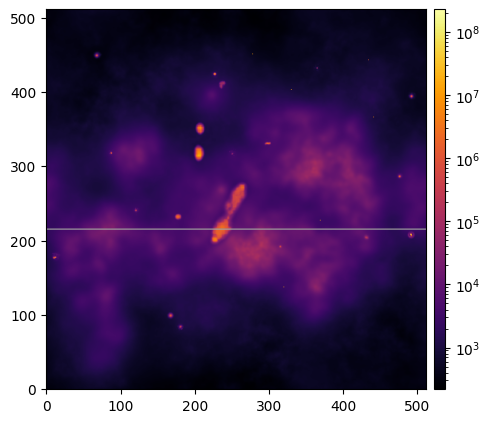

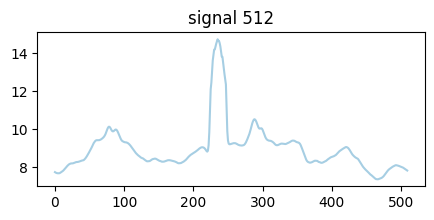

In [8]:
fname = '/Users/rf/Development/packages/aim-resolve/steering/runs/fast_vi_512c/files/5_rec.pkl'
sky_2d_512 = np.load(fname, allow_pickle=True)[0]
space_2d_512 = SignalSpace.build(shape=sky_2d_512.shape, fov=('1deg', '1deg'))
print(space_2d_512)

slc = 215 #207
signal_slc = sky_2d_512.copy()
signal_slc[:, slc] = np.nan
plot_arrays(signal_slc, norm='log', dpi=100)

sky_1d_512 = sky_2d_512[:, slc]

sky_1d_512 = np.log(sky_1d_512)
plot_1d(sky_1d_512, norm='linear', title='signal 512')

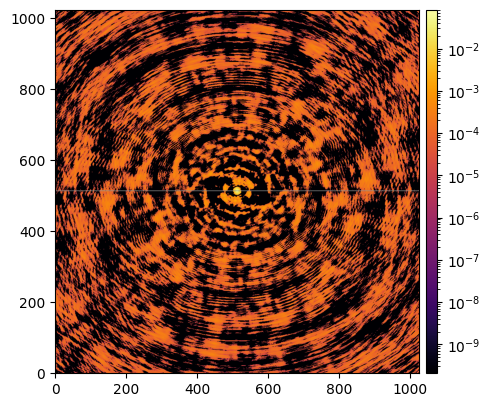

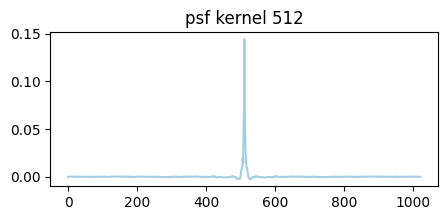

In [9]:
R, R_l, RNR, RNR_l = build_exact_responses(obs, space_2d_512)

psf_kernel_2d_512 = compute_psf_kernel(RNR_l)

slc = 512 #207
psf_kernel_slc = psf_kernel_2d_512.copy()
psf_kernel_slc[:, slc] = np.nan
plot_arrays(psf_kernel_slc, norm='log', dpi=100)

psf_kernel_1d_512 = psf_kernel_2d_512[:, slc]
plot_1d(psf_kernel_1d_512, norm='linear', title='psf kernel 512')

In [10]:
signal_bg = sky_2d_512[140, :]

peak = sky_2d_512[:, 215]
peak = np.log(peak) - 9.5
peak = np.where(peak > 0, peak, 0)
# plot_1d(peak)

slc_t0 = slice(200, 264)
signal_t0 = np.zeros_like(peak)
signal_t0[slc_t0] = peak[200:264]
signal_t0 = np.exp(signal_t0 * 3)

slc_t1 = slice(270, 334)
signal_t1 = np.zeros_like(peak)
signal_t1[slc_t1] = peak[260:324]
signal_t1 = np.exp(signal_t1 * 15)

idx_p0 = 400
ps_ker = 15
signal_p0 = np.zeros_like(peak)
signal_p0[idx_p0] = np.exp(15)

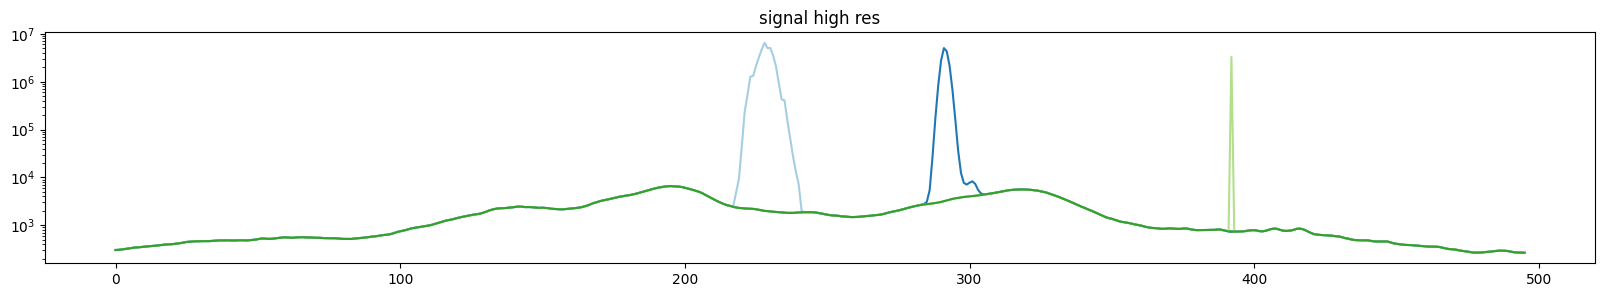

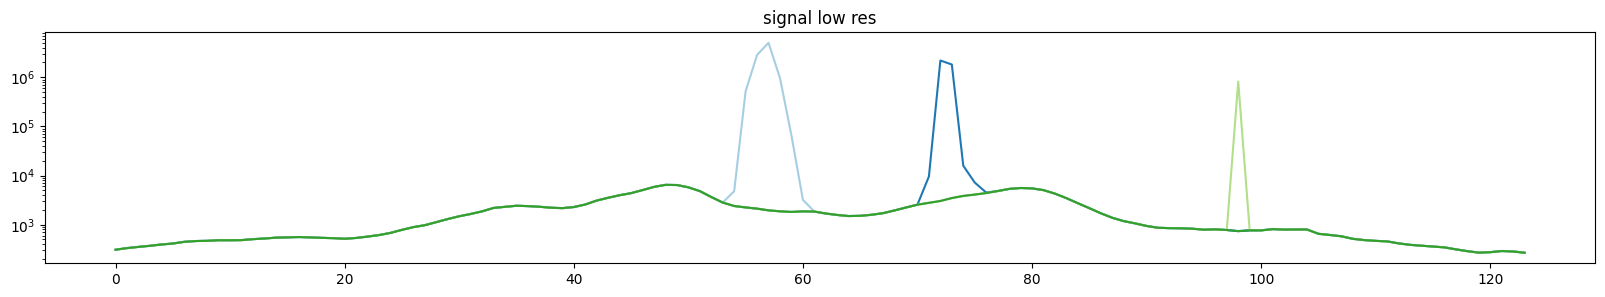

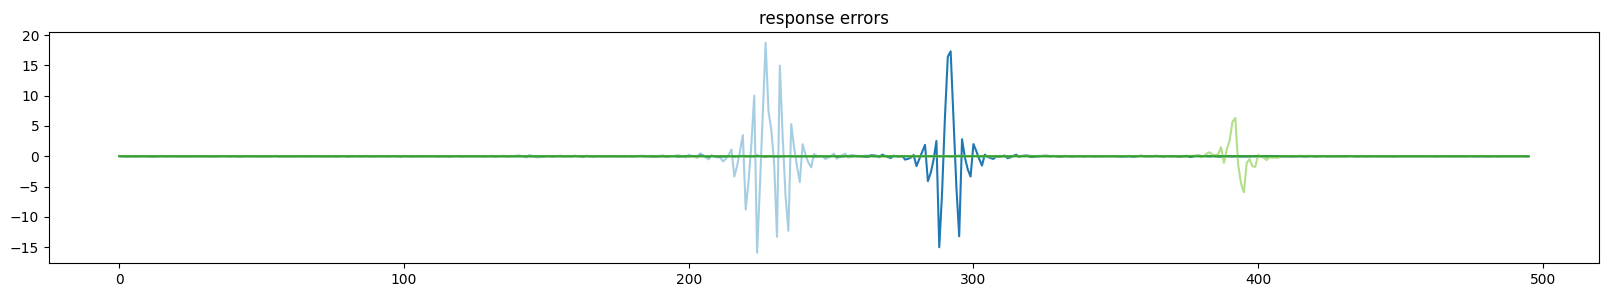

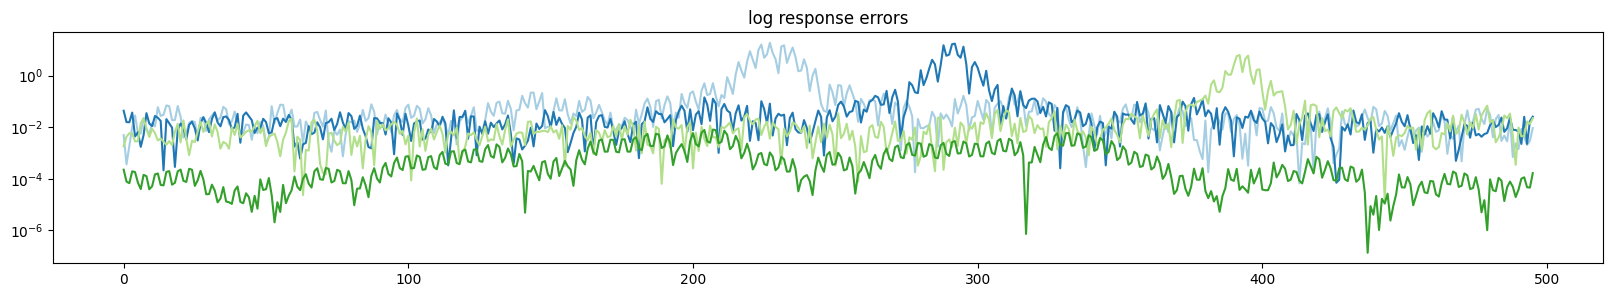

In [52]:
zoom = 4

signal_dict = {
    'sum': {'val': signal_bg + signal_t0 + signal_t1 + signal_p0, 'low': downsample(signal_bg + signal_t0 + signal_t1 + signal_p0, zoom)},
    't0': {'val': signal_t0, 'low': downsample(signal_t0, zoom), 'slc': slc_t0, 'slc_low': slice(slc_t0.start//zoom, slc_t0.stop//zoom)},
    't1': {'val': signal_t1, 'low': downsample(signal_t1, zoom), 'slc': slc_t1, 'slc_low': slice(slc_t1.start//zoom, slc_t1.stop//zoom)},
    'ps': {'val': signal_p0, 'low': downsample(signal_p0, zoom), 'idx': idx_p0, 'ker_pix': 32},
    'bg': {'val': signal_bg, 'low': downsample(signal_bg, zoom)},
    'fac': zoom,
    'shp': signal_bg.size,
}
kernel = psf_kernel_1d_512.copy()

plot_1d(*[signal_dict['bg']['val'] + sig['val'] for k,sig in signal_dict.items() if k in ['t0','t1','ps']], signal_dict['bg']['val'], norm='log', offset=8, figsize=(20,3), title='signal high res')
plot_1d(*[signal_dict['bg']['low'] + sig['low'] for k,sig in signal_dict.items() if k in ['t0','t1','ps']], signal_dict['bg']['low'], norm='log', offset=8//zoom, figsize=(20,3), title='signal low res')

rsp_err = []
low_res_err = np.zeros(signal_dict['shp'])
for k,sig in signal_dict.items():
    if isinstance(sig, dict) and k != 'sum':
        rsp_low = fft_convolve_1d(sig['low'], kernel, space_2d_512, zoom)
        rsp_low = upsample(rsp_low, zoom)
        rsp_val = fft_convolve_1d(sig['val'], kernel, space_2d_512)
        rsp_err += [rsp_val - rsp_low, ]

        if 'bg' in k:
            low_res_err += rsp_val - rsp_low
        if 't' in k:
            sig_box = np.ones(signal_dict['shp'])
            sig_box[sig['slc']] = 0
            low_res_err += (rsp_val - rsp_low) * sig_box
        if 'ps' in k:
            sig_box = np.ones(signal_dict['shp'])
            sig_box[sig['idx']-sig['ker_pix']//2:sig['idx']+sig['ker_pix']//2] = 0
            low_res_err += (rsp_val - rsp_low) * sig_box


plot_1d(*rsp_err, norm='linear', offset=8, figsize=(20,3), title='response errors')
plot_1d(*[np.abs(err) for err in rsp_err], norm='log', offset=8, figsize=(20,3), title='log response errors')


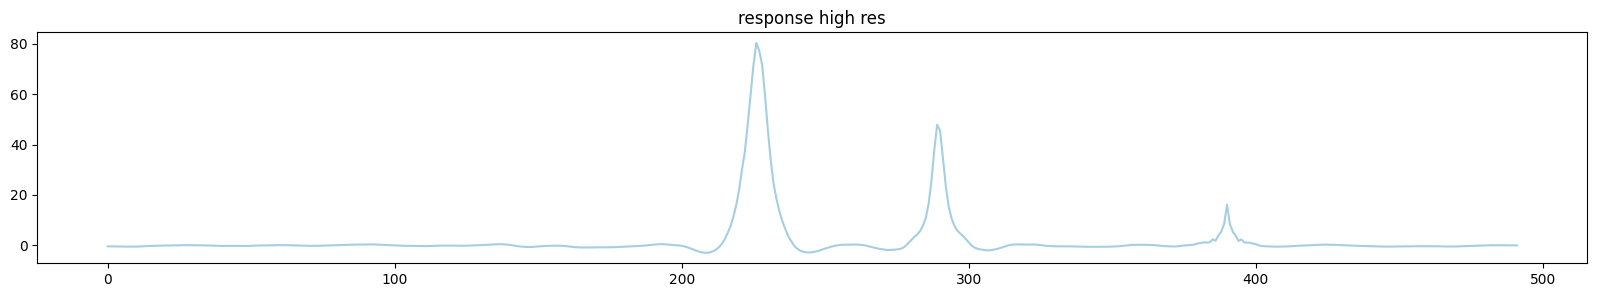

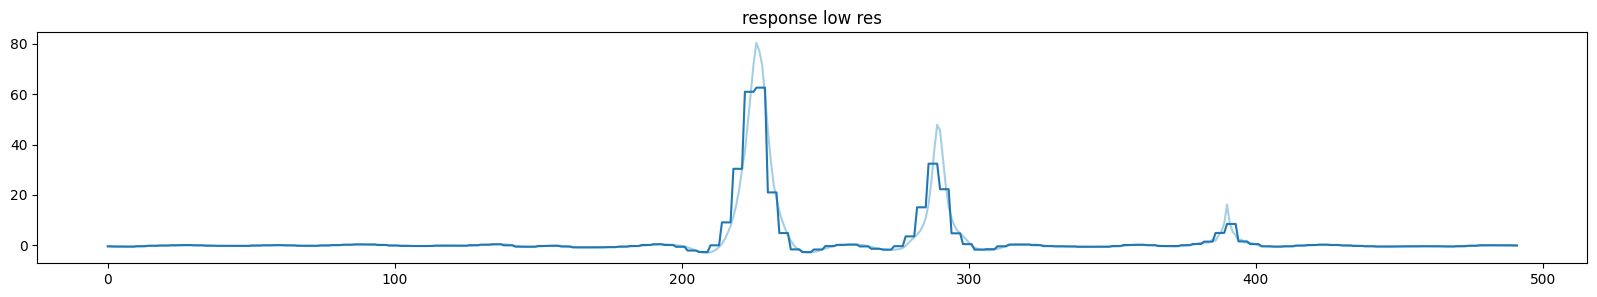

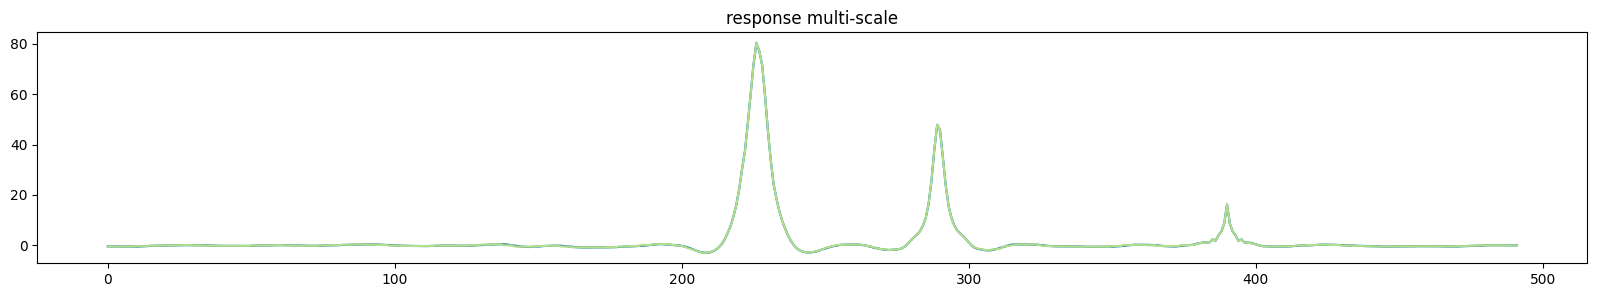

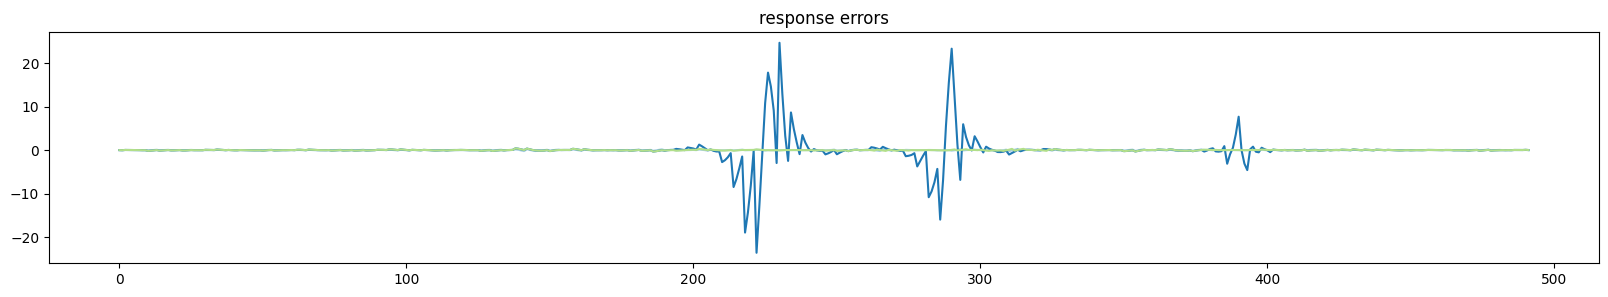

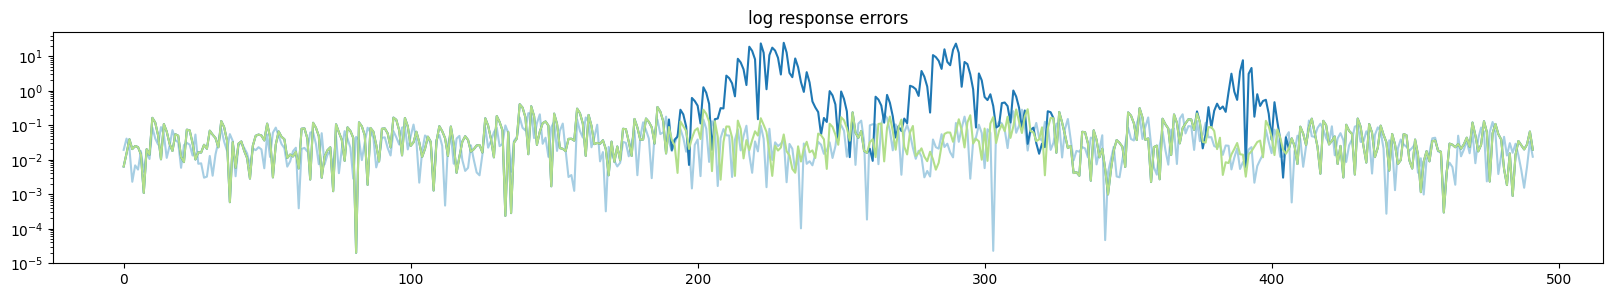

In [53]:
def multi_scale_kernel(signal_dict, kernel, space):
    signal_dict = deepcopy(signal_dict)
    fac = signal_dict['fac']

    kernel_low = downsample(kernel, signal_dict['fac'])
    response_low = fft_convolve_1d(signal_dict['sum']['low'], kernel_low, space*(1/fac))
    response_val = upsample(response_low, fac)

    for key, sig in filter(lambda x: 't' in x[0], signal_dict.items()):
        sig_val = sig['val'][sig['slc']]
        ker_val = kernel[kernel.size // 2 - sig_val.size : kernel.size // 2 + sig_val.size]
        rsp_val = fft_convolve_1d(sig_val, ker_val, space.transform(shape=sig_val.shape))

        sig_low = sig['low'][sig['slc_low']]
        ker_low = downsample(ker_val, fac)
        rsp_low = fft_convolve_1d(sig_low, ker_low, space.transform(shape=sig_val.shape)*(1/fac))

        rsp_slc = response_low[sig['slc_low']]
        rsp_sub = rsp_slc - rsp_low
        rsp_add = upsample(rsp_sub, fac) + rsp_val
        response_val[sig['slc']] = rsp_add

    for key, sig in filter(lambda x: 'ps' in x[0], signal_dict.items()):
        slc = slice(sig['idx'] - sig['ker_pix']//2, sig['idx'] + sig['ker_pix']//2)
        slc_low = slice(slc.start//fac, slc.stop//fac)

        ker_val = kernel[kernel.size//2 - sig['ker_pix']//2 : kernel.size//2 + sig['ker_pix']//2]
        rsp_val = ker_val * sig['val'][sig['idx']] * space.dis[0]

        ker_low = downsample(ker_val, fac)
        rsp_low = ker_low * sig['low'][sig['idx']//fac] * fac * space.dis[0]

        rsp_slc = response_low[slc_low]
        rsp_sub = rsp_slc - rsp_low
        rsp_add = upsample(rsp_sub, fac) + rsp_val
        response_val[slc] = rsp_add

    return response_val


response_high = fft_convolve_1d(signal_dict['sum']['val'], kernel, space_2d_512)
kernel_low = downsample(kernel, signal_dict['fac'])
response_low = fft_convolve_1d(signal_dict['sum']['low'], kernel_low, space_2d_512*(1/signal_dict['fac']))
response_low = upsample(response_low, signal_dict['fac'])


response_ms = multi_scale_kernel(signal_dict, kernel, space_2d_512)

plot_1d(response_high, offset=10, figsize=(20,3), title='response high res')
plot_1d(response_high, response_low, offset=10, figsize=(20,3), title='response low res')
plot_1d(response_high, response_high, response_ms, offset=10, figsize=(20,3), title='response multi-scale')

response_errors = [low_res_err, response_high - response_low, response_high - response_ms]

plot_1d(*response_errors, offset=10, figsize=(20,3), title='response errors')
plot_1d(*[np.abs(err) for err in response_errors], norm='log', offset=10, figsize=(20,3), title='log response errors')